In [1]:
from pathlib import Path
import copy
import time

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random_state = 42

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

report_images_dir = Path("images")
report_images_1d_dir = report_images_dir / "1d"
report_images_2d_dir = report_images_dir / "2d"
report_images_1d_dir.mkdir(parents=True, exist_ok=True)
report_images_2d_dir.mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

Using mps device


In [2]:
# Load keystroke dynamics data and select 30 random users from one session.
data_path = Path("data") / "DSL-StrongPasswordData.csv"
keystroke_dataframe = pd.read_csv(data_path)

metadata_columns = ["subject", "sessionIndex", "rep"]
feature_columns = [column for column in keystroke_dataframe.columns if column not in metadata_columns]

selected_session = 1
available_subjects = sorted(keystroke_dataframe["subject"].unique())
selected_subjects = pd.Series(available_subjects).sample(n=30, random_state=random_state).sort_values().tolist()

selected_dataframe = keystroke_dataframe[
    (keystroke_dataframe["sessionIndex"] == selected_session)
    & (keystroke_dataframe["subject"].isin(selected_subjects))
].copy()

subject_to_label = {subject: index for index, subject in enumerate(selected_subjects)}
label_to_subject = {index: subject for subject, index in subject_to_label.items()}
selected_dataframe["label"] = selected_dataframe["subject"].map(subject_to_label)
selected_dataframe = selected_dataframe.reset_index(drop=True)

print("Selected session:", selected_session)
print("Selected subjects:", selected_subjects)
print("Selected data shape:", selected_dataframe.shape)
print("Number of features:", len(feature_columns))
print(selected_dataframe["subject"].value_counts().sort_index())
selected_dataframe.head()

Selected session: 1
Selected subjects: ['s002', 's005', 's007', 's010', 's012', 's013', 's016', 's017', 's018', 's020', 's021', 's022', 's025', 's030', 's031', 's032', 's033', 's036', 's037', 's038', 's039', 's042', 's047', 's050', 's051', 's052', 's053', 's054', 's055', 's056']
Selected data shape: (1500, 35)
Number of features: 31
subject
s002    50
s005    50
s007    50
s010    50
s012    50
s013    50
s016    50
s017    50
s018    50
s020    50
s021    50
s022    50
s025    50
s030    50
s031    50
s032    50
s033    50
s036    50
s037    50
s038    50
s039    50
s042    50
s047    50
s050    50
s051    50
s052    50
s053    50
s054    50
s055    50
s056    50
Name: count, dtype: int64


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return,label
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742,0
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747,0
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945,0
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813,0
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818,0


In [3]:
# Stratified split: 80% train, 10% validation, 10% test.
train_val_data, test_data = train_test_split(
    selected_dataframe,
    test_size=0.10,
    random_state=random_state,
    stratify=selected_dataframe["label"]
)

train_data, validation_data = train_test_split(
    train_val_data,
    test_size=0.1111,  # 11.11% of 90% gives about 10% of all data
    random_state=random_state,
    stratify=train_val_data["label"]
)

train_data = train_data.reset_index(drop=True)
validation_data = validation_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)
print("Train samples per class:", train_data["label"].value_counts().sort_index().unique())
print("Validation samples per class:", validation_data["label"].value_counts().sort_index().unique())
print("Test samples per class:", test_data["label"].value_counts().sort_index().unique())

Train: (1200, 35)
Validation: (150, 35)
Test: (150, 35)
Train samples per class: [40]
Validation samples per class: [5]
Test samples per class: [5]


In [4]:
train_feature_tensor = torch.tensor(train_data[feature_columns].values, dtype=torch.float32)
feature_mean = train_feature_tensor.mean(dim=0)
feature_std = train_feature_tensor.std(dim=0)
feature_std[feature_std == 0] = 1.0

class KeystrokeDataset(Dataset):
    def __init__(self, dataframe, feature_columns, feature_mean, feature_std):
        self.features = torch.tensor(dataframe[feature_columns].values, dtype=torch.float32)
        self.labels = torch.tensor(dataframe["label"].values, dtype=torch.long)
        self.feature_mean = feature_mean
        self.feature_std = feature_std

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        features = (self.features[index] - self.feature_mean) / self.feature_std
        features = features.unsqueeze(0)  # Conv1d input shape: channels x sequence_length = 1 x 31
        label = self.labels[index]
        return features, label

batch_size = 32
train_dataset = KeystrokeDataset(train_data, feature_columns, feature_mean, feature_std)
validation_dataset = KeystrokeDataset(validation_data, feature_columns, feature_mean, feature_std)
test_dataset = KeystrokeDataset(test_data, feature_columns, feature_mean, feature_std)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("One sample shape:", train_dataset[0][0].shape)
print("Classes:", len(selected_subjects))

One sample shape: torch.Size([1, 31])
Classes: 30


In [5]:
class ConfigCNN1D(nn.Module):
    def __init__(self, conv_channels, input_length, class_count, use_batch_norm=False,
                 dropout_rate=0.0, activation_name="relu", dropout_position="classifier"):
        super().__init__()
        self.activation_name = activation_name

        def activation_layer():
            if activation_name == "relu":
                return nn.ReLU()
            if activation_name == "elu":
                return nn.ELU()
            if activation_name == "leaky_relu":
                return nn.LeakyReLU(negative_slope=0.1)
            raise ValueError(f"Unknown activation: {activation_name}")

        layers = []
        in_channels = 1
        current_length = input_length

        for out_channels in conv_channels:
            layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(out_channels))
            layers.append(activation_layer())
            if dropout_position == "conv_and_classifier" and dropout_rate > 0:
                layers.append(nn.Dropout1d(dropout_rate))
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            in_channels = out_channels
            current_length = current_length // 2

        self.features = nn.Sequential(*layers)
        flattened_size = in_channels * current_length

        classifier_layers = []
        if dropout_rate > 0:
            classifier_layers.append(nn.Dropout(dropout_rate))
        classifier_layers.append(nn.Linear(flattened_size, class_count))
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


def get_optimizer(model, optimizer_name, learning_rate):
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=learning_rate)
    if optimizer_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=learning_rate)
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

In [6]:
def run_experiment(config, epochs=20):
    torch.manual_seed(random_state)
    model = ConfigCNN1D(
        conv_channels=config["conv_channels"],
        input_length=len(feature_columns),
        class_count=len(selected_subjects),
        use_batch_norm=config.get("batch_norm", False),
        dropout_rate=config.get("dropout", 0.0),
        activation_name=config.get("activation", "relu"),
        dropout_position=config.get("dropout_position", "classifier")
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, config.get("optimizer", "adam"), config.get("learning_rate", 0.001))

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }
    best_validation_loss = float("inf")
    best_validation_accuracy = 0.0
    best_model_state = None
    selected_epoch = 0

    start_time = time.time()
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion, device)
        validation_loss, validation_accuracy = evaluate_model(model, validation_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if (validation_loss < best_validation_loss) or (
            validation_loss == best_validation_loss and validation_accuracy > best_validation_accuracy
        ):
            best_validation_loss = validation_loss
            best_validation_accuracy = validation_accuracy
            best_model_state = copy.deepcopy(model.state_dict())
            selected_epoch = epoch + 1

    training_time = time.time() - start_time
    model.load_state_dict(best_model_state)

    return model, history, {
        "dataset": "keystroke",
        "study": config["study"],
        "name": config["name"],
        "architecture_name": config.get("architecture_name", ""),
        "conv_channels": str(config["conv_channels"]),
        "dropout_value": config.get("dropout", 0.0),
        "dropout_position": config.get("dropout_position", "classifier"),
        "batch_norm": config.get("batch_norm", False),
        "activation_function": config.get("activation", "relu"),
        "optimizer": config.get("optimizer", "adam"),
        "learning_rate": config.get("learning_rate", 0.001),
        "batch_size": batch_size,
        "epochs": epochs,
        "selected_epoch": selected_epoch,
        "training_time_seconds": training_time,
        "selected_train_accuracy": history["train_accuracy"][selected_epoch - 1],
        "selected_train_loss": history["train_loss"][selected_epoch - 1],
        "selected_validation_accuracy": history["validation_accuracy"][selected_epoch - 1],
        "selected_validation_loss": history["validation_loss"][selected_epoch - 1],
        "best_validation_accuracy": max(history["validation_accuracy"]),
        "lowest_validation_loss": min(history["validation_loss"]),
        "final_training_accuracy": history["train_accuracy"][-1],
        "final_training_loss": history["train_loss"][-1],
        "notes": config.get("notes", ""),
    }

In [7]:
experiment_configs = [
    {"study": "architecture",
     "name": "architecture_A_small_baseline",
     "architecture_name": "A_small_baseline",
     "conv_channels": [16, 32],
     "dropout": 0.0,
     "dropout_position": "classifier",
     "batch_norm": False,
     "activation": "relu",
     "optimizer": "adam",
     "learning_rate": 0.001,
     "notes": "Two convolution blocks"
     },
    {"study": "architecture", "name": "architecture_B_deeper_dropout", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Three convolution blocks with dropout"},
    {"study": "architecture", "name": "architecture_C_batchnorm_dropout", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Three convolution blocks with batch norm and dropout"},
    {"study": "dropout", "name": "dropout_none", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.0, "dropout_position": "classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "No dropout"},
    {"study": "dropout", "name": "dropout_classifier_0.3", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "One dropout layer before the classifier"},
    {"study": "dropout", "name": "dropout_classifier_0.5", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.5, "dropout_position": "classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "One dropout layer before the classifier"},
    {"study": "dropout", "name": "dropout_conv_and_classifier_0.3", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "conv_and_classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Dropout after each convolution block and before classifier"},
    {"study": "batch_norm", "name": "batchnorm_off", "architecture_name": "B_deeper_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": False, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Same architecture without batch norm"},
    {"study": "batch_norm", "name": "batchnorm_on", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Same architecture with batch norm"},
    {"study": "activation", "name": "activation_relu", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Activation function comparison"},
    {"study": "activation", "name": "activation_elu", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "elu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Activation function comparison"},
    {"study": "optimizer", "name": "optimizer_adam", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Optimizer comparison"},
    {"study": "optimizer", "name": "optimizer_rmsprop", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "rmsprop", "learning_rate": 0.001, "notes": "Optimizer comparison"},
    {"study": "learning_rate", "name": "learning_rate_0.0001", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.0001, "notes": "Learning rate comparison"},
    {"study": "learning_rate", "name": "learning_rate_0.001", "architecture_name": "C_batchnorm_dropout", "conv_channels": [16, 32, 64], "dropout": 0.3, "dropout_position": "classifier", "batch_norm": True, "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "notes": "Learning rate comparison"},
]

initial_epochs = 3
experiment_results = []
experiment_histories = {}
experiment_models = {}

for config in experiment_configs:
    print("Running", config["name"])
    model, history, result = run_experiment(config, epochs=initial_epochs)
    experiment_results.append(result)
    experiment_histories[config["name"]] = history
    experiment_models[config["name"]] = model

experiment_results_dataframe = pd.DataFrame(experiment_results).sort_values(
    ["selected_validation_loss", "selected_validation_accuracy"],
    ascending=[True, False]
).reset_index(drop=True)

experiment_results_dataframe.to_csv(Path("models") / "keystroke_experiment_results.csv", index=False)
experiment_results_dataframe

Running architecture_A_small_baseline
Running architecture_B_deeper_dropout
Running architecture_C_batchnorm_dropout
Running dropout_none
Running dropout_classifier_0.3
Running dropout_classifier_0.5
Running dropout_conv_and_classifier_0.3
Running batchnorm_off
Running batchnorm_on
Running activation_relu
Running activation_elu
Running optimizer_adam
Running optimizer_rmsprop
Running learning_rate_0.0001
Running learning_rate_0.001


,dataset,study,name,architecture_name,conv_channels,dropout_value,dropout_position,batch_norm,activation_function,optimizer,...,training_time_seconds,selected_train_accuracy,selected_train_loss,selected_validation_accuracy,selected_validation_loss,best_validation_accuracy,lowest_validation_loss,final_training_accuracy,final_training_loss,notes
0,keystroke,optimizer,optimizer_rmsprop,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,rmsprop,...,0.440879,0.800000,0.883360,0.813333,0.822439,0.813333,0.822439,0.800000,0.883360,Optimizer comparison
1,keystroke,activation,activation_elu,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,elu,adam,...,0.540594,0.720833,1.370701,0.780000,1.160813,0.780000,1.160813,0.720833,1.370701,Activation function comparison
2,keystroke,architecture,architecture_C_batchnorm_dropout,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,adam,...,1.920816,0.689167,1.551242,0.780000,1.287142,0.780000,1.287142,0.689167,1.551242,Three convolution blocks with batch norm and d...
3,keystroke,batch_norm,batchnorm_on,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,adam,...,0.489194,0.689167,1.551242,0.780000,1.287142,0.780000,1.287142,0.689167,1.551242,Same architecture with batch norm
4,keystroke,activation,activation_relu,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,adam,...,0.455383,0.689167,1.551242,0.780000,1.287142,0.780000,1.287142,0.689167,1.551242,Activation function comparison
5,keystroke,optimizer,optimizer_adam,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,adam,...,0.458105,0.689167,1.551242,0.780000,1.287142,0.780000,1.287142,0.689167,1.551242,Optimizer comparison
6,keystroke,learning_rate,learning_rate_0.001,C_batchnorm_dropout,"[16, 32, 64]",0.3,classifier,True,relu,adam,...,0.469578,0.689167,1.551242,0.780000,1.287142,0.780000,1.287142,0.689167,1.551242,Learning rate comparison
7,keystroke,architecture,architecture_A_small_baseline,A_small_baseline,"[16, 32]",0.0,classifier,False,relu,adam,...,2.378949,0.537500,2.059993,0.666667,1.789812,0.666667,1.789812,0.537500,2.059993,Two convolution blocks
8,keystroke,dropout,dropout_none,B_deeper_dropout,"[16, 32, 64]",0.0,classifier,False,relu,adam,...,0.387641,0.372500,2.256666,0.480000,2.086533,0.480000,2.086533,0.372500,2.256666,No dropout
9,keystroke,architecture,architecture_B_deeper_dropout,B_deeper_dropout,"[16, 32, 64]",0.3,classifier,False,relu,adam,...,0.558674,0.261667,2.518692,0.426667,2.256342,0.426667,2.256342,0.261667,2.518692,Three convolution blocks with dropout


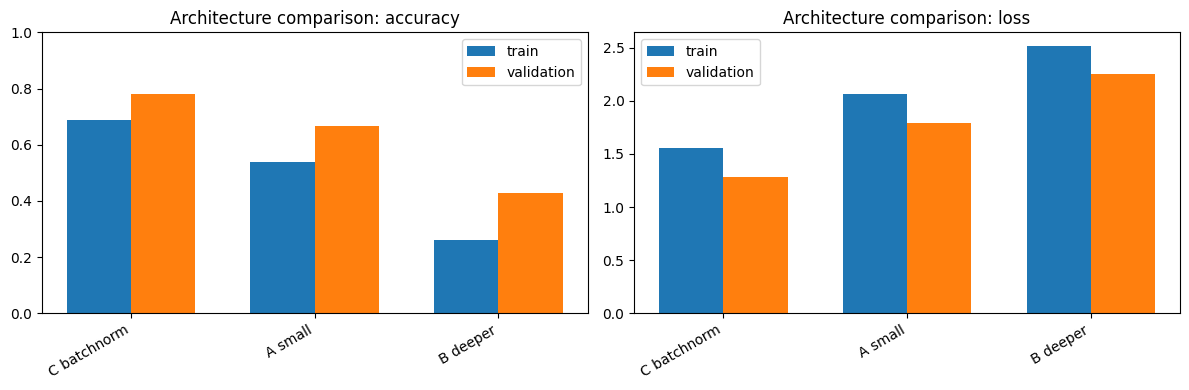

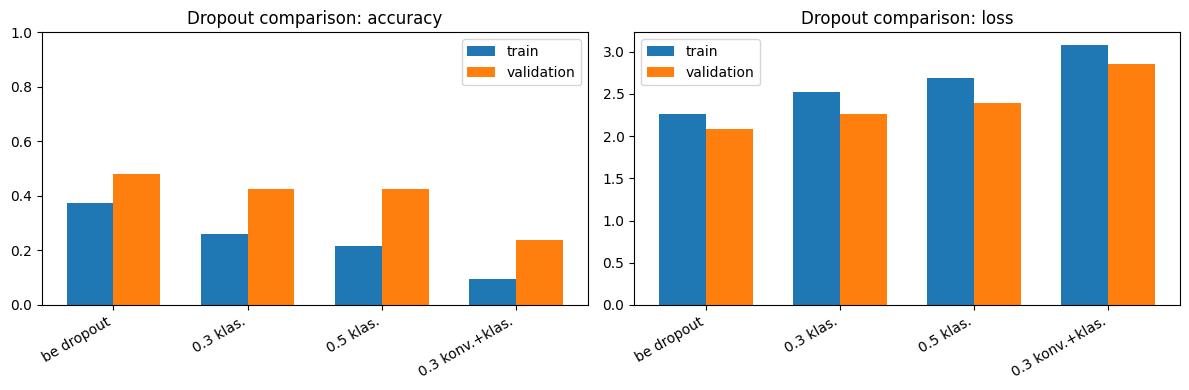

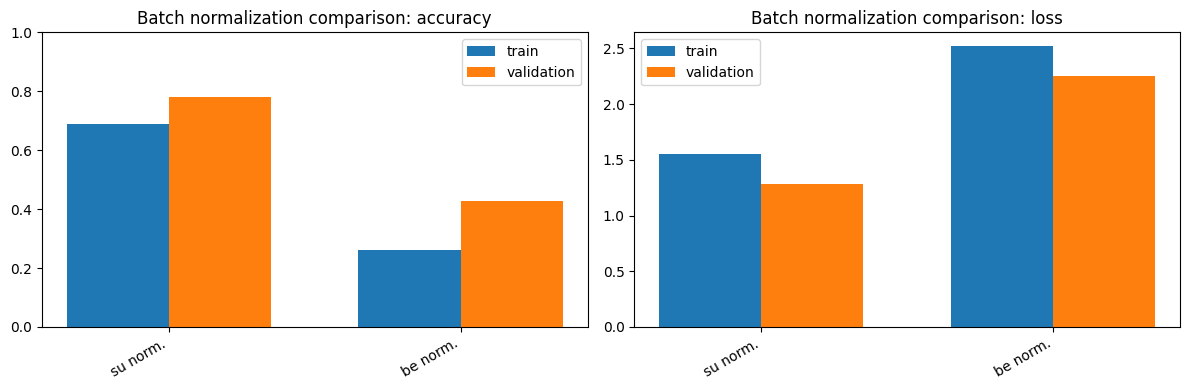

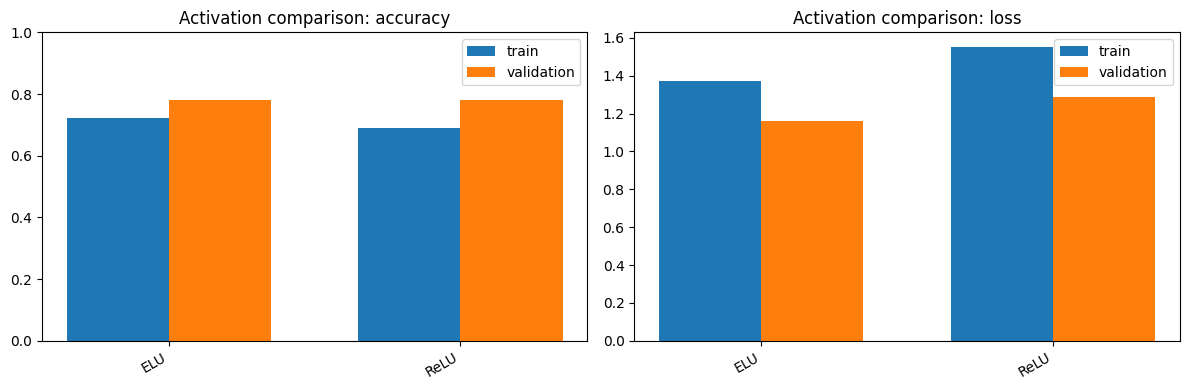

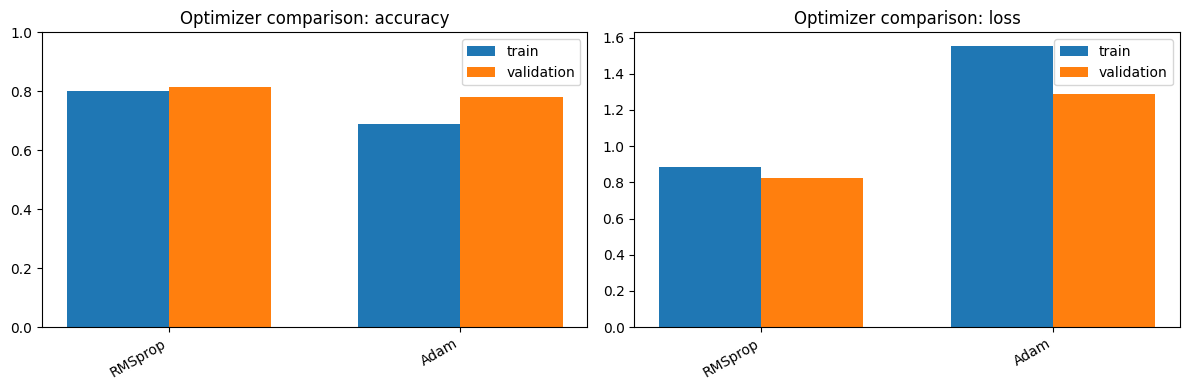

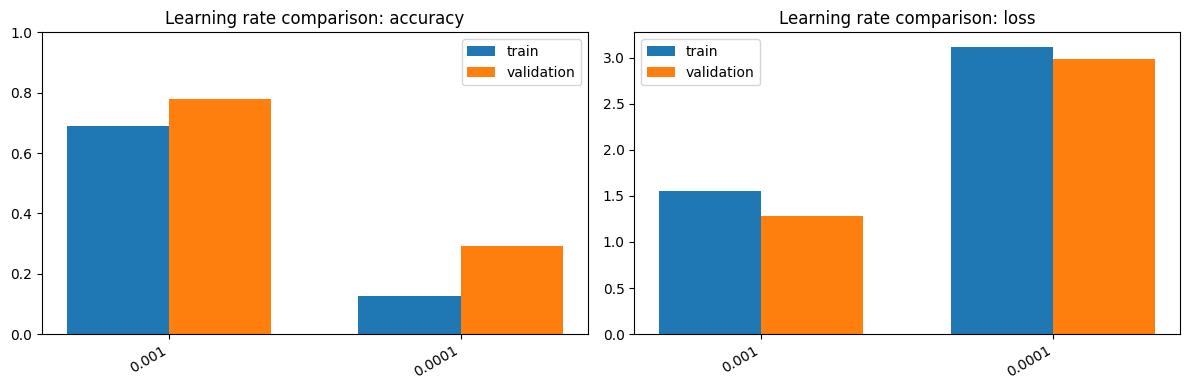

In [8]:
def plot_study_train_validation_metrics(study_name, title, filename, labels=None):
    study_data = experiment_results_dataframe[experiment_results_dataframe["study"] == study_name].copy()
    if labels is not None:
        study_data["display_name"] = study_data["name"].map(labels)
    else:
        study_data["display_name"] = study_data["name"]

    x = range(len(study_data))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar([value - width / 2 for value in x], study_data["selected_train_accuracy"], width, label="train")
    axes[0].bar([value + width / 2 for value in x], study_data["selected_validation_accuracy"], width, label="validation")
    axes[0].set_title(f"{title}: accuracy")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(study_data["display_name"], rotation=30, ha="right")
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    axes[1].bar([value - width / 2 for value in x], study_data["selected_train_loss"], width, label="train")
    axes[1].bar([value + width / 2 for value in x], study_data["selected_validation_loss"], width, label="validation")
    axes[1].set_title(f"{title}: loss")
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(study_data["display_name"], rotation=30, ha="right")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(report_images_1d_dir / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_study_train_validation_metrics("architecture", "Architecture comparison", "cnn1d_architecture_metrics.png", {
    "architecture_A_small_baseline": "A small",
    "architecture_B_deeper_dropout": "B deeper",
    "architecture_C_batchnorm_dropout": "C batchnorm",
})
plot_study_train_validation_metrics("dropout", "Dropout comparison", "cnn1d_dropout_metrics.png", {
    "dropout_none": "be dropout",
    "dropout_classifier_0.3": "0.3 klas.",
    "dropout_classifier_0.5": "0.5 klas.",
    "dropout_conv_and_classifier_0.3": "0.3 konv.+klas.",
})
plot_study_train_validation_metrics("batch_norm", "Batch normalization comparison", "cnn1d_batchnorm_metrics.png", {
    "batchnorm_off": "be norm.",
    "batchnorm_on": "su norm.",
})
plot_study_train_validation_metrics("activation", "Activation comparison", "cnn1d_activation_metrics.png", {
    "activation_relu": "ReLU",
    "activation_elu": "ELU",
})
plot_study_train_validation_metrics("optimizer", "Optimizer comparison", "cnn1d_optimizer_metrics.png", {
    "optimizer_adam": "Adam",
    "optimizer_rmsprop": "RMSprop",
})
plot_study_train_validation_metrics("learning_rate", "Learning rate comparison", "cnn1d_learning_rate_metrics.png", {
    "learning_rate_0.0001": "0.0001",
    "learning_rate_0.001": "0.001",
})

Retraining optimizer_rmsprop
Retraining activation_elu
Retraining architecture_C_batchnorm_dropout
Best final configuration: optimizer_rmsprop
Test loss: 0.29718843082586927
Test accuracy: 0.9066666666666666
              precision    recall  f1-score   support

        s002       1.00      1.00      1.00         5
        s005       1.00      1.00      1.00         5
        s007       1.00      0.60      0.75         5
        s010       1.00      0.60      0.75         5
        s012       1.00      1.00      1.00         5
        s013       0.83      1.00      0.91         5
        s016       1.00      1.00      1.00         5
        s017       1.00      1.00      1.00         5
        s018       1.00      1.00      1.00         5
        s020       1.00      1.00      1.00         5
        s021       1.00      1.00      1.00         5
        s022       1.00      1.00      1.00         5
        s025       1.00      1.00      1.00         5
        s030       0.71      1.00  

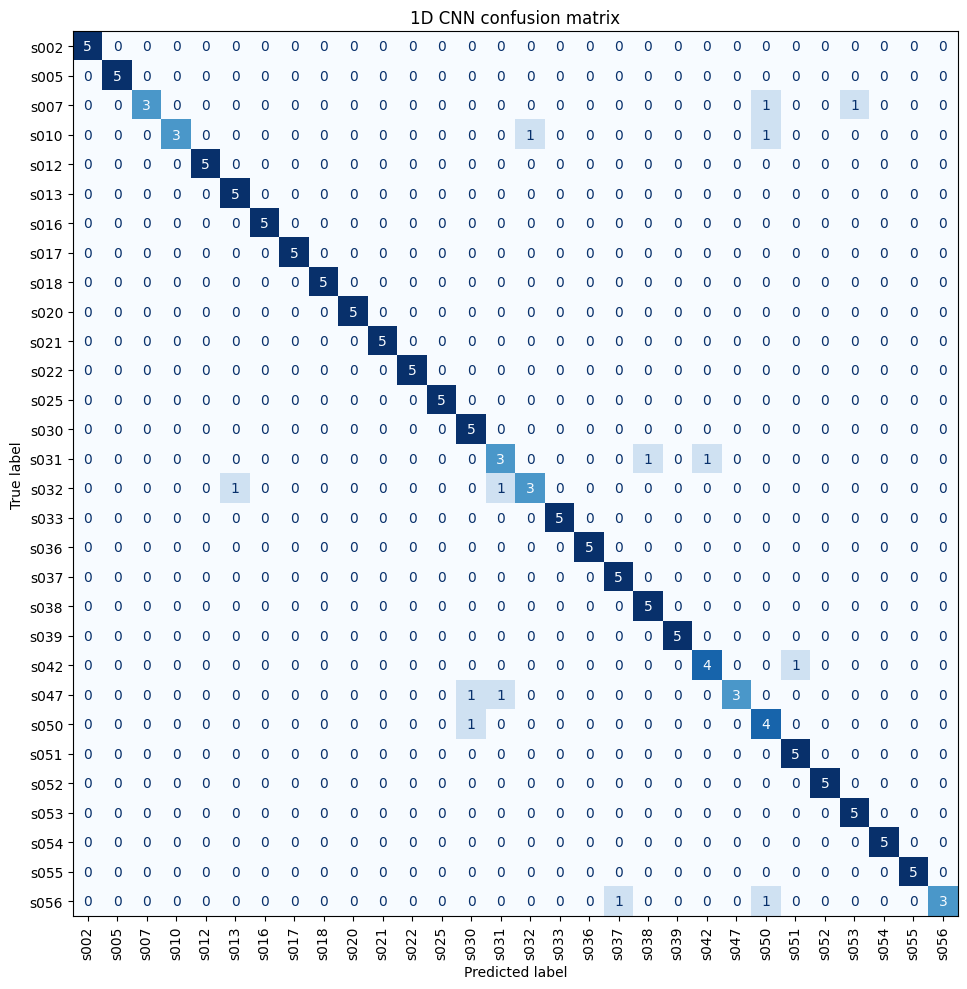

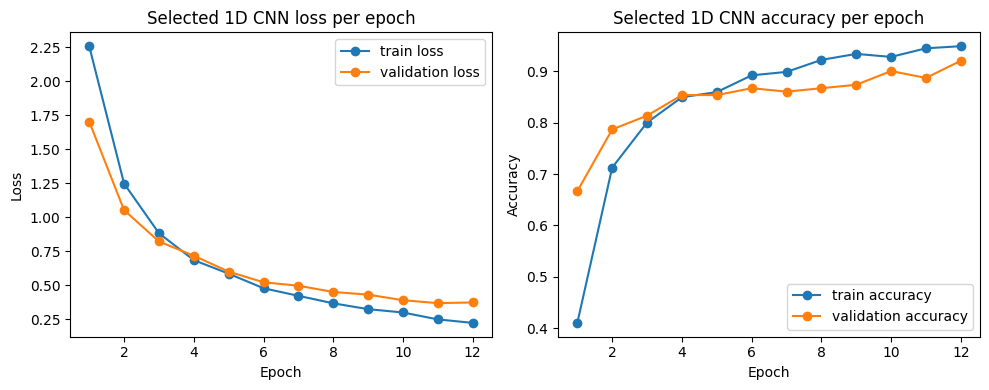

In [9]:
# Retrain the three best initial configurations for 12 epochs, then evaluate the best one on the test set.
top_configuration_names = experiment_results_dataframe.head(3)["name"].tolist()
finalist_results = []
finalist_histories = {}
finalist_models = {}

for config_name in top_configuration_names:
    config = next(config for config in experiment_configs if config["name"] == config_name)
    print("Retraining", config_name)
    model, history, result = run_experiment(config, epochs=12)
    finalist_results.append(result)
    finalist_histories[config_name] = history
    finalist_models[config_name] = model

finalist_results_dataframe = pd.DataFrame(finalist_results).sort_values(
    ["selected_validation_loss", "selected_validation_accuracy"],
    ascending=[True, False]
).reset_index(drop=True)
finalist_results_dataframe.to_csv(Path("models") / "keystroke_finalist_results.csv", index=False)
finalist_results_dataframe

best_config_name = finalist_results_dataframe.iloc[0]["name"]
best_model = finalist_models[best_config_name]
best_history = finalist_histories[best_config_name]
print("Best final configuration:", best_config_name)

criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = evaluate_model(best_model, test_loader, criterion, device)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

all_labels = []
all_predictions = []
best_model.eval()
with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = best_model(features)
        predictions = outputs.argmax(dim=1).cpu()
        all_predictions.extend(predictions.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=[label_to_subject[index] for index in range(len(selected_subjects))],
    zero_division=0
))

confusion = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=[label_to_subject[index] for index in range(len(selected_subjects))]).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False,
)
ax.set_title("1D CNN confusion matrix")
fig.tight_layout()
fig.savefig(report_images_1d_dir / "cnn1d_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

epochs_axis = range(1, len(best_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, best_history["train_loss"], marker="o", label="train loss")
axes[0].plot(epochs_axis, best_history["validation_loss"], marker="o", label="validation loss")
axes[0].set_title("Selected 1D CNN loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_axis, best_history["train_accuracy"], marker="o", label="train accuracy")
axes[1].plot(epochs_axis, best_history["validation_accuracy"], marker="o", label="validation accuracy")
axes[1].set_title("Selected 1D CNN accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(report_images_1d_dir / "cnn1d_best_model_epochs.png", dpi=180, bbox_inches="tight")
plt.show()